In [1]:
import os
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
from copy import deepcopy

from inferagni.plot import truth_color, samples_color, DPI

/home/harrison/miniforge3/envs/proteus/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/harrison/.var/app/com.visualstudio.code/config', but the default location, /home/harrison/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [2]:
# %config InlineBackend.figure_format = 'retina'

In [3]:
outdir = "output/"
planet = "TOI-421_b"

outdir_planet = os.path.join(outdir, planet)
os.makedirs(outdir_planet, exist_ok=True)

In [4]:
samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv") ,skiprows=1, sep=",", encoding="utf-8")

ntruth = len(truth)

# get last samples from samps
end_frac = 0.05
nsamp = int(len(samps)*end_frac)
samps = samps.iloc[-nsamp:]

In [5]:
print(samps.keys())

Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 'log_Kzz_max', 'μ_phot', 'r_phot', 'log_vmr_H2',
       'log_vmr_CO2', 'log_vmr_H2O', 'log_vmr_H2S', 't_surf'],
      dtype='str')


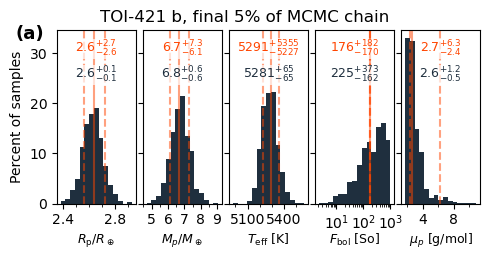

In [36]:

fig,ax = plt.subplots(1,ntruth,figsize=(5,2.5),sharey=True)

text_bbox = dict(facecolor='w', alpha=0.7, edgecolor='none',pad=0.05)

for i in range(ntruth):
    k = truth["key"].iloc[i]

    this_samp = ia.util.nondimen(deepcopy(samps[k]), k)

    pctle = 0.0
    ymin = np.percentile(this_samp, pctle)
    ymax = np.percentile(this_samp, 100-pctle)

    nbins = 16
    if ia.util.varprops[k].log:
        ax[i].set_xscale("log")
        bins = np.logspace(np.log10(ymin), np.log10(ymax), nbins)
    else:
        bins = np.linspace(ymin, ymax, nbins)

    # samples from mcmc
    ax[i].hist(this_samp, bins=bins, weights=np.full_like(this_samp, 100.0/len(this_samp)),
               color=samples_color, edgecolor="none",)

    this_med = np.median(this_samp)
    this_erp = np.percentile(this_samp, 84)-this_med
    this_erm = this_med-np.percentile(this_samp, 16)

    # observations
    al = 0.5

    this_truth = deepcopy(truth.iloc[i])
    obs_val = ia.util.nondimen(this_truth["value"], k)
    ax[i].axvline(obs_val, color=truth_color, ls="-", alpha=al)

    obs_err_plu = obs_val + ia.util.nondimen(this_truth["plus"], k)
    ax[i].axvline(obs_err_plu, color=truth_color, ls="--", alpha=al)

    obs_err_min = obs_val - ia.util.nondimen(this_truth["minus"], k)
    ax[i].axvline(obs_err_min, color=truth_color, ls="--", alpha=al)

    # text = ia.util.varprops[k].label
    # ax[i].text(0.5, 0.5, text, transform=ax[i].transAxes, ha="left", va="center",
    #                fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.1))

    ax[i].set_xlabel(ia.util.varprops[k].label_short, fontsize=9, labelpad=0.1)

    # custom tick spacing and formatter
    fmt = "%.1f"
    match k:
        case "r_phot":
            ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.4))
            ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
        case "mass_tot":
            dy = 1
            ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
            ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))
        case "Teff":
            ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(300))
            ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(100))
            fmt = "%.0f"
        case "instellation":
            fmt = "%.0f"
        case "μ_phot":
            # ax[i].set_xscale("log")
            ax[i].xaxis.set_major_locator(mpl.ticker.MultipleLocator(4))
            ax[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(2))
            # ax[i].xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.0f"))

    # annotate
    ax[i].text(0.5,0.80,str(fmt)%this_med + r"$^{+" + str(fmt)%this_erp + r"}_{-" + str(fmt)%this_erm + r"}$",
                    va='top', ha='center', color=samples_color,
                   transform=ax[i].transAxes,
                    fontsize=9, zorder=99, bbox=text_bbox)
    ax[i].text(0.5,0.95,str(fmt)%obs_val + r"$^{+" + str(fmt)%obs_err_plu + r"}_{-" + str(fmt)%obs_err_min + r"}$",
                    va='top', ha='center', color=truth_color,
                   transform=ax[i].transAxes,
                    fontsize=9, zorder=99, bbox=text_bbox)


fig.text(0.04,0.96, "(a)", ha="left", va="top", fontsize=13, fontweight="bold")
ax[0].set_ylabel(f"Percent of samples")
fig.align_xlabels()
fig.tight_layout(w_pad=-0.5)

planet_name = planet.replace("_", " ")
fig.suptitle(f"{planet_name}, final {end_frac*100:.0f}% of MCMC chain", fontsize=12, va='bottom', y=0.96)


fig.savefig(os.path.join(outdir,"ia_demo_truth.pdf"), dpi=ia.plot.DPI, bbox_inches="tight")
plt.show()

0.00859645275842955 [[np.float64(0.005208761024373414)], [np.float64(0.01123716889057345)]]
-0.5548051595687866 [[np.float64(0.8539118766784668)], [np.float64(0.4842791223526001)]]
2.5981210470199 [[np.float64(0.4938144063949279)], [np.float64(1.1715557146072357)]]


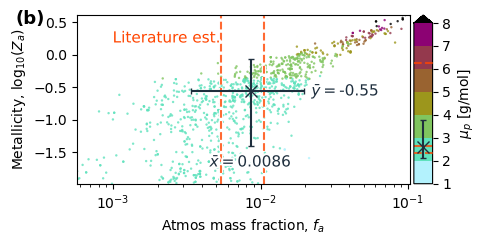

In [63]:
fig,ax = plt.subplots(1,1,figsize=(5,2.5))

ckey = "μ_phot"
xkey = "frac_atm" ; xfmt = "%.4f"
ykey = "logZ"     ; yfmt = "%.2f"

al = 0.4
ms = 3

if ia.util.varprops[ckey].log:
    c = 10**(samps[ckey].values)
else:
    c = samps[ckey].values
mask = np.argsort(c)[::-1]

x = ia.util.nondimen(samps[xkey].iloc[mask], xkey)
y = ia.util.nondimen(samps[ykey].iloc[mask], ykey)
c = ia.util.nondimen(c[mask], ckey)

# create scalarmappable with defined boundaries
cmap = deepcopy(ia.util.varprops[ckey].cmap)
cmap.set_over("k")
norm = mpl.colors.BoundaryNorm(boundaries=np.arange(1, 9, 1.0), ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

# colorbar
cbar = fig.colorbar(sm, ax=ax, label=ia.util.varprops[ckey].label, pad=0.01, extend='max', aspect=9)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))

_pe_text = [mpl.patheffects.Stroke(linewidth=3, foreground='w'), mpl.patheffects.Normal()]

# add paper constraints
al = 0.8
obs_col = truth_color
cbar.ax.axhline(ia.util.nondimen(truth[truth["key"]==ckey]["value"], ckey), c=obs_col, ls='-', alpha=al)
cbar.ax.axhline(ia.util.nondimen(truth[truth["key"]==ckey]["value"], ckey) + ia.util.nondimen(truth[truth["key"]==ckey]["plus"], ckey),c=obs_col , ls='--', zorder=10, alpha=al)
cbar.ax.axhline(ia.util.nondimen(truth[truth["key"]==ckey]["value"], ckey) - ia.util.nondimen(truth[truth["key"]==ckey]["minus"], ckey),c=obs_col, ls='--', zorder=10, alpha=al)
for xx in (1.05/100,0.54/100):
    ax.axvline(xx, color=obs_col, ls='--', alpha=al, path_effects=_pe_text)
ax.annotate("Literature est.",(xx,np.percentile(y,98)), xytext=(0,0), textcoords='offset points',
                 ha='right', va='top', rotation=0, rotation_mode='anchor',
                 color=obs_col, fontsize=11, path_effects=_pe_text)


# mcmc result
x_med = np.median(x); x_err=[[np.median(x)-np.percentile(x, 16)], [np.percentile(x, 84)-np.median(x)]]
x_txt = r"$\bar{x}=$" + str(xfmt)%x_med

print(x_med, x_err)

y_med = np.median(y); y_err=[[np.median(y)-np.percentile(y, 16)], [np.percentile(y, 84)-np.median(y)]]
y_txt = r"$\bar{y}=$" + str(yfmt)%y_med

print(y_med, y_err)

ax.scatter(x,y, c=c, s=ms,  alpha=al, cmap=sm.get_cmap(), norm=sm.norm, edgecolors="none", rasterized=True)
ax.errorbar([x_med], [y_med], xerr=x_err, yerr=y_err,
            zorder=20, capsize=2, color=samples_color, lw=1.5, marker='x', markersize=8)

ax.annotate(x_txt,(x_med, y_med-y_err[0][0]), xytext=(0,-5), textcoords='offset points',
                 ha='center', va='top', rotation=0, rotation_mode='anchor',
                 color=samples_color, fontsize=11, path_effects=_pe_text)

ax.annotate(y_txt,(x_med+x_err[1][0], y_med), xytext=(5,0), textcoords='offset points',
                 ha='left', va='center', rotation=0, rotation_mode='anchor',
                 color=samples_color, fontsize=11, path_effects=_pe_text)

c_med = np.median(c); c_err=[[np.median(c)-np.percentile(c, 16)], [np.percentile(c, 84)-np.median(c)]]
print(c_med, c_err)

cbar.ax.errorbar([0.5], [c_med], yerr=c_err,
                 c=samples_color, markersize=8, marker='x', zorder=21,capsize=2, lw=1.5)


if ia.util.varprops[xkey].log:
    ax.set_xscale("log")
if ia.util.varprops[ykey].log:
    ax.set_yscale("log")
ax.set_xlabel(ia.util.varprops[xkey].label)
ax.set_ylabel(ia.util.varprops[ykey].label)

ax.set_xlim(np.amin(x), np.amax(x))
ax.set_ylim(np.amin(y), np.amax(y))

# ax.legend(loc='lower right', fontsize=9, framealpha=1)

fig.text(0.04,0.96, "(b)", ha="left", va="top", fontsize=13, fontweight="bold")

fig.tight_layout()
fig.savefig(os.path.join(outdir,"ia_demo_litcomp.pdf"), dpi=DPI, bbox_inches="tight")
plt.show()